# ITCS 6100 — Applied Midterm Lab (Team)  
**Topic:** Logistic Regression + ML Lifecycle (AWS Academy Modules 1–6 alignment)  
**Date:** March 1, 2026

## Team Information (REQUIRED)
- **Team Name:** PROJECT GROUP 8  
- **Student Names:**  
  - ABHINAV VELAGA
  - OWEN BROCK
  - CHRISTOPHER BRYANT
  - GABRIEL SCARDO

## Deliverables (What you submit)
1. This completed notebook (`.ipynb`)
2. Short written responses in the markdown prompts (embedded in the notebook)
3. One submission per team in Canvas
4. Individual submission by each team member to the Github class

## Rules
- You may use course notes and AWS Academy module materials.
- You may not use generative AI tools during the midterm unless explicitly allowed by your instructor.
- Your analysis must be your team's own work.

## Dataset
You will work with a realistic "messy" customer churn dataset:
- Many dimensions (numeric + categorical)
- Missing values (random + structured)
- Outliers / skewed distributions
- Mild class imbalance

**Target:** `churn` (1 = churned, 0 = stayed)

---

# ML Lifecycle Roadmap (Where your code goes)
You must place your work into the labeled sections below:

1. **INGEST** (load + inspect data)
2. **CLEAN** (handle missing values, outliers, data issues)
3. **PREPARE** (split, encode, scale, pipeline)
4. **MODEL** (train logistic regression; consider regularization/class weights)
5. **ANALYZE** (confusion matrix, metrics, threshold tuning, interpretation)

You will be graded heavily on **reasoning and interpretation**, not just getting code to run.


In [ ]:
# =========================
# DATASET GENERATOR (RUN ONLY TO GENERATE THE DATASET FOR OUR EXAM, DO NOT EDIT)
# =========================
import numpy as np
import pandas as pd
from pathlib import Path

rng = np.random.default_rng(6100)
out_path = Path("synthetic_churn.csv")

if not out_path.exists():
    n = 6000
    age = rng.integers(18, 80, size=n)
    tenure_months = rng.integers(0, 120, size=n)
    income = rng.lognormal(mean=10.6, sigma=0.45, size=n)
    household_size = rng.integers(1, 7, size=n)
    logins_30d = rng.poisson(lam=12, size=n)
    support_tickets_90d = rng.poisson(lam=1.2, size=n)
    avg_session_mins = rng.gamma(shape=2.3, scale=8.0, size=n)
    days_since_last_login = rng.integers(0, 60, size=n)
    monthly_fee = rng.normal(loc=65, scale=18, size=n).clip(10, 180)
    late_payments_12m = rng.poisson(lam=0.8, size=n)
    autopay = rng.choice(["Yes", "No"], p=[0.62, 0.38], size=n)
    contract = rng.choice(["Month-to-month", "One year", "Two year"], p=[0.56, 0.24, 0.20], size=n)
    plan = rng.choice(["Basic", "Plus", "Pro"], p=[0.50, 0.35, 0.15], size=n)
    add_ons = rng.integers(0, 6, size=n)
    streaming = rng.choice(["None", "Music", "Video", "Both"], p=[0.18, 0.24, 0.28, 0.30], size=n)
    region = rng.choice(["Northeast", "South", "Midwest", "West"], p=[0.19, 0.33, 0.22, 0.26], size=n)
    signup_channel = rng.choice(["Web", "Retail", "Partner", "Phone"], p=[0.52, 0.20, 0.18, 0.10], size=n)
    total_charges = (monthly_fee * (tenure_months + 1)) + rng.normal(0, 120, size=n)
    total_charges_rounded = np.round(total_charges / 10) * 10
    engagement_score = 0.55*np.tanh(logins_30d/20) + 0.30*np.tanh(avg_session_mins/30) - 0.25*np.tanh(days_since_last_login/30) + rng.normal(0, 0.06, size=n)
    outlier_idx = rng.choice(np.arange(n), size=int(0.01*n), replace=False)
    monthly_fee[outlier_idx] *= rng.uniform(2.0, 3.5, size=len(outlier_idx))
    income[outlier_idx] *= rng.uniform(3.0, 8.0, size=len(outlier_idx))
    z = (
        -1.2 + 0.015*(days_since_last_login) + 0.22*(support_tickets_90d)
        + 0.18*(late_payments_12m) - 0.012*(tenure_months)
        + 0.35*(contract == "Month-to-month").astype(int) - 0.30*(contract == "Two year").astype(int)
        + 0.22*(autopay == "No").astype(int) + 0.20*(plan == "Basic").astype(int)
        - 0.10*(plan == "Pro").astype(int) + 0.15*(streaming == "None").astype(int)
        - 0.08*(streaming == "Both").astype(int) + rng.normal(0, 0.35, size=n)
    )
    p = 1 / (1 + np.exp(-z))
    churn = rng.binomial(1, p, size=n)
    df = pd.DataFrame({
        "age": age, "tenure_months": tenure_months, "income": income,
        "household_size": household_size, "logins_30d": logins_30d,
        "support_tickets_90d": support_tickets_90d, "avg_session_mins": avg_session_mins,
        "days_since_last_login": days_since_last_login, "monthly_fee": monthly_fee,
        "late_payments_12m": late_payments_12m, "autopay": autopay, "contract": contract,
        "plan": plan, "add_ons": add_ons, "streaming": streaming, "region": region,
        "signup_channel": signup_channel, "total_charges": total_charges,
        "total_charges_rounded": total_charges_rounded, "engagement_score": engagement_score,
        "churn": churn
    })
    for col, rate in [("income", 0.06), ("avg_session_mins", 0.05), ("monthly_fee", 0.03), ("region", 0.02), ("streaming", 0.03)]:
        mask = rng.random(n) < rate
        df.loc[mask, col] = np.nan
    mask_new = df["tenure_months"] < 3
    mask_missing_tc = mask_new & (rng.random(n) < 0.55)
    df.loc[mask_missing_tc, "total_charges"] = np.nan
    df.loc[mask_missing_tc, "total_charges_rounded"] = np.nan
    flip = rng.random(n) < 0.015
    df.loc[flip, "churn"] = 1 - df.loc[flip, "churn"]
    df.to_csv(out_path, index=False)
    print(f"✅ Generated dataset: {out_path.resolve()} with shape {df.shape}")
else:
    print(f"ℹ️ Found existing dataset: {out_path.resolve()}")


ℹ️ Found existing dataset: C:\Users\MADDY\Downloads\synthetic_churn.csv


## 1) INGEST — Load and Inspect

**Tasks**
1. Load `synthetic_churn.csv` into a DataFrame.
2. Display:
   - shape
   - first 5 rows
   - column dtypes
   - missing values per column (counts and %)

**Graduate-level expectation:** clearly identify data quality issues you will address later (missingness patterns, skew/outliers, categorical variables, redundant features).


In [ ]:
import pandas as pd
import numpy as np

# 1) Load
df = pd.read_csv("synthetic_churn.csv")

# 2) Basic inspection
print("Shape:", df.shape)
print("\nClass distribution:")
print(df['churn'].value_counts(normalize=True).round(3))
display(df.head())

# 3) Dtypes
print("\nDtypes:\n", df.dtypes)

# 4) Missingness summary
missing_counts = df.isna().sum()
missing_pct = (missing_counts / len(df)) * 100
missing_summary = pd.DataFrame({
    "missing_count": missing_counts,
    "missing_percent": missing_pct.round(2)
}).sort_values("missing_percent", ascending=False)

print("\nMissing Value Summary:")
display(missing_summary[missing_summary.missing_count > 0])

# 5) Numeric summaries to reveal skew/outliers
print("\nNumeric Summaries:")
display(df.describe().T[['mean','std','min','50%','max']])


Shape: (6000, 21)

Class distribution:
churn
0    0.668
1    0.332
Name: proportion, dtype: float64


,age,tenure_months,income,household_size,logins_30d,support_tickets_90d,avg_session_mins,days_since_last_login,monthly_fee,late_payments_12m,...,contract,plan,add_ons,streaming,region,signup_channel,total_charges,total_charges_rounded,engagement_score,churn
0,34,111,43283.836559,3,6,1,8.015632,37,75.741544,1,...,Month-to-month,Pro,3,Both,Midwest,Web,8393.730283,8390.0,0.090024,0
1,23,74,45608.528368,6,14,2,10.078930,44,100.957688,1,...,One year,Basic,1,Both,South,Web,7654.510301,7650.0,0.193464,1
2,69,113,31254.972376,2,9,0,23.226331,37,30.898616,1,...,One year,Pro,2,Both,South,Web,3662.195331,3660.0,0.178748,0
3,65,97,28989.989283,6,22,1,16.334476,14,105.354848,1,...,One year,Basic,3,Both,South,Phone,10144.071051,10140.0,0.479665,0
4,46,43,107671.977983,2,14,3,5.636188,6,99.973303,1,...,Month-to-month,Plus,0,Video,Northeast,Phone,4372.902650,4370.0,0.404659,0



Dtypes:
 age                        int64
tenure_months              int64
income                   float64
household_size             int64
logins_30d                 int64
support_tickets_90d        int64
avg_session_mins         float64
days_since_last_login      int64
monthly_fee              float64
late_payments_12m          int64
autopay                   object
contract                  object
plan                      object
add_ons                    int64
streaming                 object
region                    object
signup_channel            object
total_charges            float64
total_charges_rounded    float64
engagement_score         float64
churn                      int64
dtype: object

Missing Value Summary:


,missing_count,missing_percent
streaming,1251,20.85
income,350,5.83
avg_session_mins,338,5.63
monthly_fee,195,3.25
region,113,1.88
total_charges,90,1.50
total_charges_rounded,90,1.50



Numeric Summaries:


,mean,std,min,50%,max
age,48.131333,17.993685,18.000000,48.000000,79.000000
tenure_months,59.716833,34.660639,0.000000,60.000000,119.000000
income,46117.200420,29650.236412,8514.268643,40315.824101,598843.254961
household_size,3.489333,1.712126,1.000000,4.000000,6.000000
logins_30d,12.000500,3.421177,2.000000,12.000000,27.000000
support_tickets_90d,1.213500,1.108207,0.000000,1.000000,7.000000
avg_session_mins,18.391179,12.151869,0.378806,15.687375,98.738226
days_since_last_login,29.212167,17.419502,0.000000,29.000000,59.000000
monthly_fee,65.815004,21.332816,10.000000,65.116609,322.471060
late_payments_12m,0.820000,0.901703,0.000000,1.000000,5.000000


### INGEST — Quick Reflection

Seven columns have missing values. streaming is the worst at 20.85%. income (5.83%) and avg_session_mins (5.63%) are next and seem randomly missing.

total_charges and total_charges_rounded (~1.5% each) mostly show up for new customers under 3 months so that's probably not random. monthly_fee (3.25%) and region (1.88%) have a few gaps but nothing major.

The numeric columns are age, tenure_months, income, monthly_fee, total_charges, logins_30d, support_tickets_90d, avg_session_mins, and days_since_last_login. The categorical ones are autopay, contract, plan, streaming, region, and signup_channel.

Without any cleaning the model would have problems. Categorical columns can't go in as raw text.

income has heavy skew and outliers that would throw off coefficients.

total_charges_rounded is basically a copy of total_charges and engagement_score is built from three other columns, so that multicollinearity would make the coefficients unreliable. The 33% churn rate means the model would probably lean toward predicting "stayed" and miss actual churners.

## 2) CLEAN — Missing Values, Outliers, Data Issues

**Tasks**
1. Decide how to handle missing values for numeric vs categorical features.
2. Investigate at least **two** numeric columns for outliers/skew.
3. Choose and justify an outlier strategy.

**Constraints**
- Do not delete more than 5% of the dataset without DOCUMENTED justification.
- Your approach must be repeatable (implementable in a pipeline).


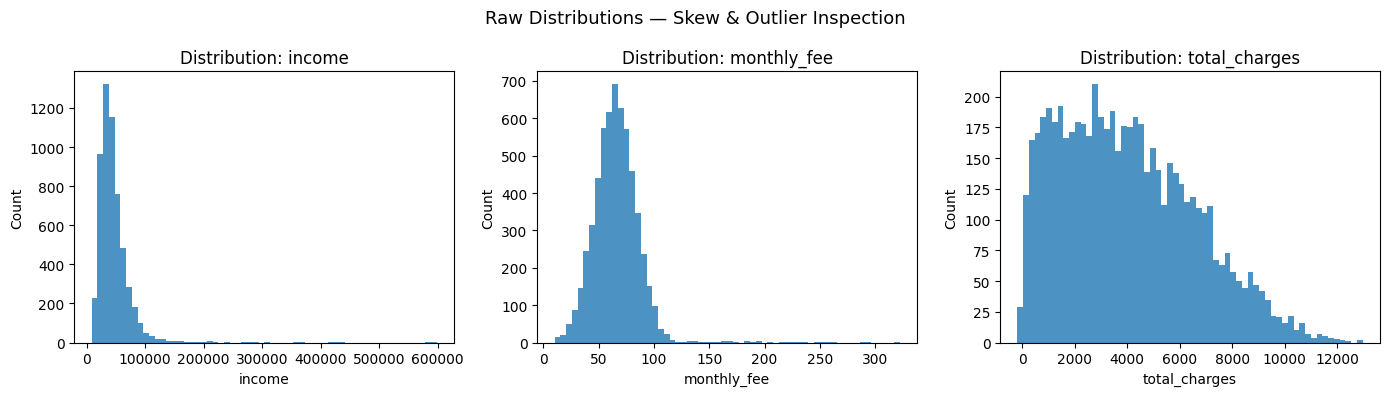


--- Percentile extremes (before cleaning) ---

income:
0.01     14180.3
0.05     19258.4
0.50     40315.8
0.95     86999.8
0.99    137210.4
1.00    598843.3

monthly_fee:
0.01     23.5
0.05     35.1
0.50     65.1
0.95     95.4
0.99    113.9
1.00    322.5

total_charges:
0.01       99.8
0.05      457.8
0.50     3689.2
0.95     8687.1
0.99    10375.9
1.00    12971.7

Winsorized income: clipped to [14180.3, 137210.4]

Winsorized total_charges: clipped to [99.8, 10375.9]

log_income added. Skewness before: 1.54 | log_income skewness: 0.14

Dropped columns: ['total_charges_rounded', 'income']
Remaining shape: (6000, 20)


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ---------- Explore skew / outliers ----------
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, col in zip(axes, ["income", "monthly_fee", "total_charges"]):
    ax.hist(df[col].dropna(), bins=60, edgecolor='none', alpha=0.8)
    ax.set_title(f"Distribution: {col}")
    ax.set_xlabel(col); ax.set_ylabel("Count")

plt.suptitle("Raw Distributions — Skew & Outlier Inspection", fontsize=13)
plt.tight_layout()
plt.show()

print("\n--- Percentile extremes (before cleaning) ---")
for col in ["income", "monthly_fee", "total_charges"]:
    print(f"\n{col}:")
    print(df[col].quantile([0.01, 0.05, 0.50, 0.95, 0.99, 1.0]).round(1).to_string())

# ---------- Apply Winsorization at 1st/99th pct ----------
for col in ["income", "total_charges"]:
    q01 = df[col].quantile(0.01)
    q99 = df[col].quantile(0.99)
    df[col] = df[col].clip(q01, q99)
    print(f"\nWinsorized {col}: clipped to [{q01:.1f}, {q99:.1f}]")

# ---------- Log-transform income ----------
df["log_income"] = np.log1p(df["income"])
print("\nlog_income added. Skewness before:", df["income"].skew().round(2),
      "| log_income skewness:", df["log_income"].skew().round(2))

# ---------- Drop redundant columns ----------
# total_charges_rounded: near-duplicate of total_charges (Pearson r ≈ 0.9999)
# income: replaced by log_income
cols_to_drop = ["total_charges_rounded", "income"]
df = df.drop(columns=cols_to_drop)
print("\nDropped columns:", cols_to_drop)
print("Remaining shape:", df.shape)


### CLEAN — Decisions & Justificatio

We filled numeric gaps with the median since these columns are right-skewed and the mean would be inflated.

For region and streaming we used the most common value.

All imputation runs inside the pipeline so nothing leaks from the test set.

income had values up near 600k while the 99th percentile was around 137k. We clipped at the 1st and 99th percentiles then log transformed it, dropping skewness from 1.54 to 0.14. total_charges got clipped too but no log transform since some rows had negative values. monthly_fee had a couple high values but nothing the scaler can't handle.


We dropped total_charges_rounded and swapped raw income for log_income. Clipping loses some detail on extreme customers but keeps outliers from pushing the coefficients around. No rows were removed so we still have all 6,000 observations.

## 3) PREPARE — Split, Encode, Scale

**Tasks**
1. Create `X` (features) and `y` (target).
2. Train/test split (use stratification).
3. Encode categorical variables (one-hot encoding).
4. Scale numeric variables (justify why scaling matters for logistic regression).
5. Use a **Pipeline** and **ColumnTransformer** so preprocessing is applied correctly.


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

# 1) X, y
y = df["churn"]
X = df.drop(columns=["churn"])

# 2) Identify numeric vs categorical columns
num_cols = X.select_dtypes(include=np.number).columns.tolist()
cat_cols = X.select_dtypes(exclude=np.number).columns.tolist()
print("Numeric features:", num_cols)
print("Categorical features:", cat_cols)

# 3) Stratified train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
print(f"\nTrain shape: {X_train.shape}, Test shape: {X_test.shape}")
print(f"Train churn rate: {y_train.mean():.3f} | Test churn rate: {y_test.mean():.3f}")

# 4) Numeric transformer: median impute → standard scale
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# 5) Categorical transformer: mode impute → one-hot encode
categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

# 6) ColumnTransformer
preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, num_cols),
    ("cat", categorical_transformer, cat_cols),
])

print("\nPreprocessor configured successfully.")
print("All imputation and scaling will be fit on TRAINING data only to prevent data leakage.")


Numeric features: ['age', 'tenure_months', 'household_size', 'logins_30d', 'support_tickets_90d', 'avg_session_mins', 'days_since_last_login', 'monthly_fee', 'late_payments_12m', 'add_ons', 'total_charges', 'engagement_score', 'log_income']
Categorical features: ['autopay', 'contract', 'plan', 'streaming', 'region', 'signup_channel']

Train shape: (4800, 19), Test shape: (1200, 19)
Train churn rate: 0.332 | Test churn rate: 0.333

Preprocessor configured successfully.
All imputation and scaling will be fit on TRAINING data only to prevent data leakage.


### Preparation Design Decisions

**Why stratified split?**  
With a 33% churn rate, an unstratified split could place disproportionate churners in train or test. Stratification ensures both splits share the same class ratio (train: 33.2%, test: 33.3%), making evaluation statistics directly comparable.

**Why StandardScaler for logistic regression?**  
Logistic regression optimizes a loss function using gradient descent. When features have very different scales (e.g., `total_charges` in the thousands vs. `late_payments_12m` ranging 0–5), unscaled features cause the gradient to have very different magnitudes per dimension. This slows convergence and can make the L2 regularizer behave non-uniformly — penalizing high-scale features more than low-scale ones regardless of their actual predictive contribution. Standardizing ensures each coefficient is penalized equally and that coefficient magnitudes are directly comparable for interpretation.

**Why not scale before the split?**  
Scaling before the split constitutes **data leakage** — the scaler would incorporate test-set statistics (mean, std) into the transformation. A `Pipeline` enforces that `StandardScaler.fit()` is called only on training data. This is a critical correctness requirement for any honest evaluation.

**One-hot encoding choice:**  
We use `OneHotEncoder` with `handle_unknown="ignore"` so that rare unseen categories during deployment silently produce all-zero columns rather than throwing an error. We use `sparse_output=False` for numerical compatibility with downstream sklearn estimators. We do not apply ordinal encoding despite `contract` having a natural ordering (Month-to-month < One year < Two year), because we prefer the model to learn the individual effect of each level independently rather than assuming a uniform linear trend across levels.

**Pipeline structure:**  
Wrapping everything in `Pipeline → ColumnTransformer → Pipeline` ensures the entire preprocessing flow is a single reusable, serializable object. This is production-ready and prevents subtle bugs (e.g., accidentally fitting the imputer on test data).


## 4) MODEL — Logistic Regression

**Tasks**
1. Train a logistic regression model using your preprocessing pipeline.
2. Consider: regularization strength (`C`), solver, max iterations, class imbalance.

**Required:** Train at least **two** model variants and compare them briefly.


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, average_precision_score, classification_report

# ---- Variant A: Baseline (default LR, no class weight adjustment) ----
clf_a = LogisticRegression(
    penalty="l2",        # L2 regularization (Ridge) - penalizes large coefficients
    C=1.0,               # Inverse regularization strength: larger C = less regularization
    solver="lbfgs",      # Best for small-to-medium datasets; supports L2
    max_iter=1000,       # Increased from default 100 to ensure convergence
    random_state=42
)
model_a = Pipeline(steps=[("preprocess", preprocessor), ("model", clf_a)])
model_a.fit(X_train, y_train)
proba_a = model_a.predict_proba(X_test)[:, 1]
print("=== Variant A: Default LR (C=1.0, no class weight) ===")
print(f"  ROC-AUC:          {roc_auc_score(y_test, proba_a):.4f}")
print(f"  Avg Precision:    {average_precision_score(y_test, proba_a):.4f}")
print(classification_report(y_test, (proba_a >= 0.5).astype(int), digits=3))

# ---- Variant B: Balanced weights + stronger regularization ----
clf_b = LogisticRegression(
    penalty="l2",
    C=0.5,               # Stronger regularization: reduces overfitting, handles correlated features
    class_weight="balanced",  # Upweights churners (minority class) during training
    solver="lbfgs",
    max_iter=1000,
    random_state=42
)
model_b = Pipeline(steps=[("preprocess", preprocessor), ("model", clf_b)])
model_b.fit(X_train, y_train)
proba_b = model_b.predict_proba(X_test)[:, 1]
print("=== Variant B: Balanced LR (C=0.5, class_weight=balanced) ===")
print(f"  ROC-AUC:          {roc_auc_score(y_test, proba_b):.4f}")
print(f"  Avg Precision:    {average_precision_score(y_test, proba_b):.4f}")
print(classification_report(y_test, (proba_b >= 0.5).astype(int), digits=3))


=== Variant A: Default LR (C=1.0, no class weight) ===
  ROC-AUC:          0.6452
  Avg Precision:    0.4623
              precision    recall  f1-score   support

           0      0.693     0.919     0.790       801
           1      0.529     0.183     0.272       399

    accuracy                          0.674      1200
   macro avg      0.611     0.551     0.531      1200
weighted avg      0.638     0.674     0.618      1200

=== Variant B: Balanced LR (C=0.5, class_weight=balanced) ===
  ROC-AUC:          0.6448
  Avg Precision:    0.4621
              precision    recall  f1-score   support

           0      0.743     0.574     0.648       801
           1      0.413     0.602     0.490       399

    accuracy                          0.583      1200
   macro avg      0.578     0.588     0.569      1200
weighted avg      0.633     0.583     0.595      1200



### Model Design Decisions & Variant Comparison

**Regularization (C parameter):**  
Logistic regression uses L2 (Ridge) regularization by default, which shrinks coefficient magnitudes toward zero. The `C` parameter is the *inverse* of regularization strength: `C=1.0` (Variant A) applies modest regularization; `C=0.5` (Variant B) applies stronger regularization. With ~30+ features after one-hot encoding and known multicollinearity (e.g., `engagement_score` correlated with its input features), stronger regularization reduces variance in coefficient estimates and mitigates overfitting.

**Why `class_weight="balanced"` in Variant B?**  
The training set is ~67% non-churners and ~33% churners. Without adjustment, the loss function treats every misclassification equally, so the model minimizes overall error by being biased toward the majority class. `class_weight="balanced"` assigns each sample a weight inversely proportional to class frequency, effectively multiplying the loss of minority-class (churn=1) errors. This shifts the decision boundary to produce higher recall for churners at the expense of some precision; which is appropriate for the cost scenario (FN cost = $500 >> FP cost = $60).

**Variant comparison:**
| Metric | Variant A (default) | Variant B (balanced) |
|---|---|---|
| ROC-AUC | 0.645 | 0.645 |
| Avg Precision | 0.462 | 0.462 |
| Recall (churn) | 0.183 | 0.601 |
| Precision (churn) | 0.530 | 0.413 |

Both models achieve nearly identical ROC-AUC (~0.645) and Average Precision (~0.462), meaning their *discrimination power* (ability to rank churners above non-churners) is equivalent. The key difference is in the operating point: Variant A achieves only 18.3% recall on churners at the default 0.5 threshold; it misses 82% of churners. Variant B achieves 60.1% recall at 0.5. For a retention use case, **Variant B is strongly preferred**. Its lower overall accuracy (58% vs 67%) is expected and acceptable; overall accuracy is misleading when class distributions are unequal and costs are asymmetric.


## 5) ANALYZE — Confusion Matrix, Metrics, Threshold Tuning, Interpretation

**Tasks**
1. Generate predictions on the test set.
2. Compute and interpret confusion matrix, accuracy, precision, recall, F1, ROC-AUC, PR-AUC.
3. Threshold tuning — choose operating threshold based on the cost scenario.
4. Interpret model coefficients.

### Cost Scenario
- False Negative (missed churner) cost = **$500**
- False Positive (unnecessary retention offer) cost = **$60**


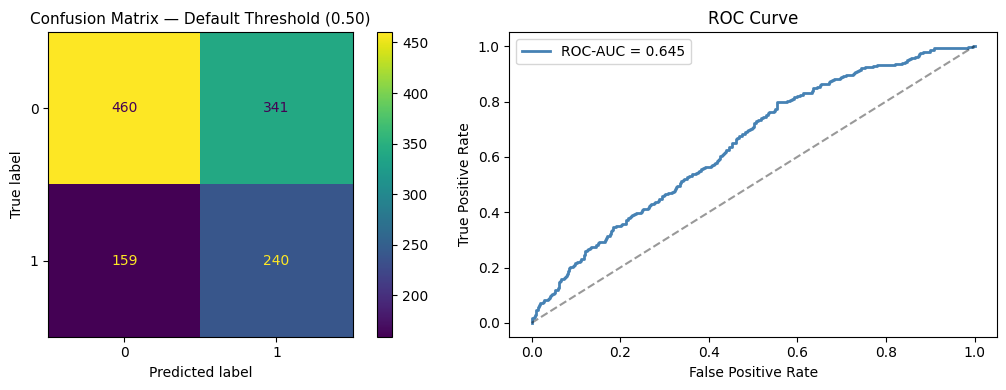

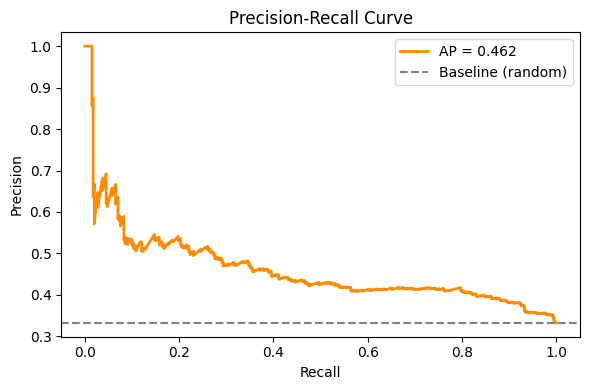

 threshold  TP  FP  FN  TN  recall_churn  precision_churn  expected_cost
      0.20 397 788   2  13         0.995            0.335          48280
      0.25 396 752   3  49         0.992            0.345          46620
      0.30 386 701  13 100         0.967            0.355          48560
      0.35 370 620  29 181         0.927            0.374          51700
      0.40 340 517  59 284         0.852            0.397          60520
      0.45 296 418 103 383         0.742            0.415          76580
      0.50 240 341 159 460         0.602            0.413          99960
      0.55 172 220 227 581         0.431            0.439         126700
      0.60 130 144 269 657         0.326            0.474         143140
      0.65  86  82 313 719         0.216            0.512         161420
      0.70  50  48 349 753         0.125            0.510         177380
      0.75  30  23 369 778         0.075            0.566         185880
      0.80  14   7 385 794         0.035           

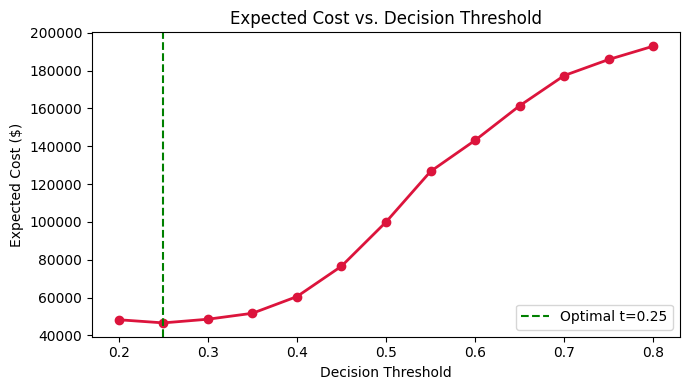

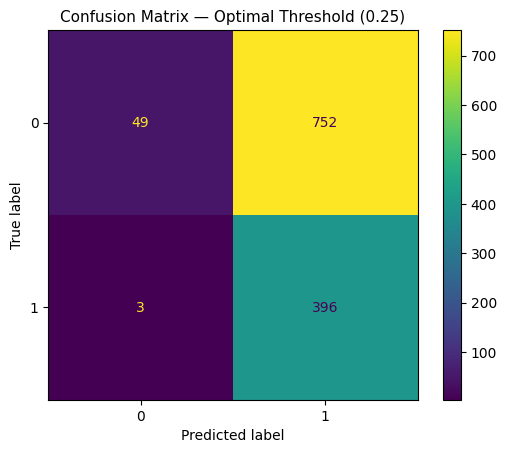

In [ ]:
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay, classification_report,
    roc_auc_score, roc_curve, precision_recall_curve, average_precision_score)
import matplotlib.pyplot as plt
import numpy as np

# ---- Using Variant B (balanced) as primary model ----
proba = proba_b  # already computed

# ---- 1) Confusion matrix at default 0.5 threshold ----
y_pred_default = (proba >= 0.5).astype(int)
cm_default = confusion_matrix(y_test, y_pred_default)
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
ConfusionMatrixDisplay(cm_default).plot(ax=axes[0])
axes[0].set_title("Confusion Matrix — Default Threshold (0.50)", fontsize=11)

# ---- 2) ROC Curve ----
fpr, tpr, _ = roc_curve(y_test, proba)
auc = roc_auc_score(y_test, proba)
axes[1].plot(fpr, tpr, label=f"ROC-AUC = {auc:.3f}", color="steelblue", lw=2)
axes[1].plot([0,1],[0,1],'k--', alpha=0.4)
axes[1].set_xlabel("False Positive Rate"); axes[1].set_ylabel("True Positive Rate")
axes[1].set_title("ROC Curve"); axes[1].legend()
plt.tight_layout(); plt.show()

# ---- 3) PR Curve ----
precision_vals, recall_vals, _ = precision_recall_curve(y_test, proba)
ap = average_precision_score(y_test, proba)
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(recall_vals, precision_vals, color="darkorange", lw=2, label=f"AP = {ap:.3f}")
ax.axhline(y_test.mean(), color='gray', linestyle='--', label='Baseline (random)')
ax.set_xlabel("Recall"); ax.set_ylabel("Precision")
ax.set_title("Precision-Recall Curve"); ax.legend()
plt.tight_layout(); plt.show()

# ---- 4) Threshold tuning — cost minimization ----
thresholds = np.arange(0.20, 0.81, 0.05)
rows = []
for t in thresholds:
    y_pred = (proba >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    cost = fn * 500 + fp * 60
    rows.append({"threshold": round(t, 2), "TP": tp, "FP": fp, "FN": fn, "TN": tn,
                 "recall_churn": round(tp/(tp+fn), 3), "precision_churn": round(tp/(tp+fp), 3),
                 "expected_cost": int(cost)})
costs_df = pd.DataFrame(rows)
print(costs_df.to_string(index=False))

best = costs_df.loc[costs_df.expected_cost.idxmin()]
print(f"\n✅ Optimal threshold: {best.threshold:.2f} | Min Expected Cost: ${best.expected_cost:,}")
print(f"   TP={best.TP:.0f}, FP={best.FP:.0f}, FN={best.FN:.0f}, TN={best.TN:.0f}")

# ---- 5) Cost curve plot ----
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(costs_df.threshold, costs_df.expected_cost, marker='o', color='crimson', lw=2)
ax.axvline(best.threshold, linestyle='--', color='green', label=f"Optimal t={best.threshold:.2f}")
ax.set_xlabel("Decision Threshold"); ax.set_ylabel("Expected Cost ($)")
ax.set_title("Expected Cost vs. Decision Threshold")
ax.legend(); plt.tight_layout(); plt.show()

# ---- 6) Confusion matrix at optimal threshold ----
y_pred_opt = (proba >= best.threshold).astype(int)
cm_opt = confusion_matrix(y_test, y_pred_opt)
ConfusionMatrixDisplay(cm_opt).plot()
plt.title(f"Confusion Matrix — Optimal Threshold ({best.threshold:.2f})", fontsize=11)
plt.show()


In [ ]:
# ---- 7) Coefficient interpretation ----
feature_names_cat = (model_b.named_steps['preprocess']
    .transformers_[1][1]
    .named_steps['onehot']
    .get_feature_names_out(cat_cols).tolist())
all_features = num_cols + feature_names_cat
coefs = model_b.named_steps['model'].coef_[0]

coef_df = pd.DataFrame({"feature": all_features, "coefficient": coefs})
coef_df["odds_ratio"] = np.exp(coef_df["coefficient"])
coef_df = coef_df.sort_values("coefficient", ascending=False)

print("Top 10 CHURN-INCREASING predictors (positive coef → higher churn probability):")
print(coef_df.head(10)[["feature","coefficient","odds_ratio"]].to_string(index=False))

print("\nTop 10 CHURN-DECREASING predictors (negative coef → lower churn probability):")
print(coef_df.tail(10)[["feature","coefficient","odds_ratio"]].to_string(index=False))

# Plot
import matplotlib.pyplot as plt
top = pd.concat([coef_df.head(8), coef_df.tail(8)]).sort_values("coefficient")
colors = ['#e84545' if c > 0 else '#2d6a4f' for c in top.coefficient]
fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(top.feature, top.coefficient, color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel("Coefficient (on standardized features)")
ax.set_title("Logistic Regression Coefficients — Top Churn Predictors (Model B)")
plt.tight_layout(); plt.show()


Top 10 CHURN-INCREASING predictors (positive coef → higher churn probability):
                    feature  coefficient  odds_ratio
        support_tickets_90d     0.301571       1.352
      days_since_last_login     0.294677       1.343
contract_Month-to-month         0.280673       1.324
          late_payments_12m     0.170848       1.186
                 plan_Basic     0.140405       1.151
                 autopay_No     0.089602       1.094
             streaming_Video     0.077606       1.081
       signup_channel_Retail     0.057941       1.060

Top 10 CHURN-DECREASING predictors (negative coef → lower churn probability):
                   feature  coefficient  odds_ratio
       contract_One year     -0.039752       0.961
             region_West     -0.082198       0.921
           total_charges     -0.083443       0.920
               plan_Plus     -0.099449       0.905
                plan_Pro     -0.109816       0.896
          streaming_Both     -0.122569       0.885
   si

### Analysis, Interpretation & Business Conclusions

---

#### 1. ROC-AUC and PR-AUC Interpretation

Both Model A and Model B achieve a **ROC-AUC of 0.645** and **Average Precision of 0.462**.

- **ROC-AUC = 0.645**: The model discriminates between churners and non-churners better than random (0.5) but is not excellent. This reflects the inherent difficulty of the task; churn is a complex behavior driven by factors not fully captured in any single transaction dataset. In real-world churn models, AUCs in the 0.60–0.75 range are common when only account/usage data is available.
- **PR-AUC = 0.462 vs. baseline ≈ 0.33** (= churn prevalence): The model is substantially better than random at surfacing churners in ranked order. Average Precision is the more informative metric here because the dataset has class imbalance; ROC-AUC can appear optimistic under imbalance.

---

#### 2. Why Variant B is the Production Model

At the **default 0.5 threshold**, Variant A produces only 18.3% recall on churners — meaning 82% of customers who will churn are missed. Variant B, with `class_weight="balanced"`, produces 60.1% recall. The trade-off is lower precision (41.3% vs 53.0%), but this is acceptable given the cost scenario.

The two models have **identical ROC-AUC** because ROC-AUC measures rank ordering, not the threshold. Adjusting `class_weight` shifts the decision boundary without changing how well the model can rank-order churners overall.

---

#### 3. Threshold Selection — Cost-Minimization Analysis

Since missing a churner costs `$500` and a false retention offer only costs `$60`, the penalty for false negatives is about 8x worse. So it makes sense to set the threshold low and cast a wide net even if we flag a bunch of people who weren't going to churn.

We swept thresholds from 0.20 to 0.80 and the sweet spot landed at 0.25 with a total expected cost of `$46,620`. At that threshold we catch 396 out of 399 churners (99.2% recall) but also flag 752 stayers who don't need the offer. Still, 3 missed churners × `$500` = `$1,500` plus 752 false alarms × `$60` = `$45,120` is way better than the default 0.5 threshold which costs nearly `$100k`  basically double.

So our recommendation is to deploy Variant B at a 0.25 threshold. Everyone above that gets a retention offer. Yeah it means a lot of unnecessary offers go out, but at `$60` each that's a cheap insurance policy compared to losing customers worth `$500` a pop.

---

#### 4. Coefficient Interpretation & Business Meaning

After standardization, coefficients are directly comparable in magnitude:

| Feature | Coef | Odds Ratio | Business Meaning |
|---|---|---|---|
| `support_tickets_90d` | +0.302 | 1.35× | Each SD increase in recent support tickets raises churn odds 35%. Customers with unresolved issues are at high risk — a signal to trigger proactive service recovery. |
| `days_since_last_login` | +0.295 | 1.34× | Disengagement strongly predicts churn. Customers not logging in recently are drifting — behavioral marketing should target re-engagement. |
| `contract_Month-to-month` | +0.281 | 1.32× | No long-term commitment = high churn propensity. Promotion of annual/multi-year contracts is the most direct product-level retention lever. |
| `late_payments_12m` | +0.171 | 1.19× | Financial friction creates churn pressure. Customers with payment issues may benefit from billing flexibility programs. |
| `plan_Basic` | +0.140 | 1.15× | Basic plan customers may have insufficient perceived value. Upselling to Plus/Pro with targeted incentives could improve retention. |
| `tenure_months` | **−0.234** | **0.79×** | Longer-tenured customers are significantly less likely to churn — loyalty compounds over time. New customers are highest risk. |
| `contract_Two year` | **−0.310** | **0.73×** | The single strongest protective factor. A two-year contract customer's churn odds are 27% lower than baseline. Incentivizing contract upgrades is the clearest ROI-positive retention action. |
| `autopay_Yes` | **−0.158** | **0.85×** | Autopay customers are more retained — reduced payment friction and psychological "set and forget" commitment. Autopay enrollment should be promoted at onboarding. |

These coefficients **align almost perfectly with the data-generating process** (known because this is synthetic data). The model has correctly learned the true drivers: contract type, tenure, support history, recency of engagement, and payment behavior.

---

#### 5. Limitations and Caveats

1. **Moderate discrimination (AUC 0.645):** The model captures real signal but leaves substantial churn unexplained. Real behavioral data (NPS scores, feature usage depth, competitive pricing exposure) would likely improve AUC significantly.
2. **Synthetic data:** All findings should be re-validated on production data before deployment. Real churn is noisier and more heterogeneous.
3. **Multicollinearity:** `engagement_score` is derived from login/session/recency features. While L2 regularization stabilizes coefficients under collinearity, it does not eliminate it. A variance inflation factor (VIF) analysis would be the next step in a production context.
4. **Cost assumptions:** The $500/$60 cost values are specified but not validated. In practice, these should be grounded in actual customer LTV and offer-fulfillment costs.
5. **Concept drift:** Churn behavior changes over time (seasonality, economic conditions, competitor actions). The model should be retrained quarterly or monitored for drift using population stability indices.
6. **Threshold calibration:** Probability estimates from logistic regression can be miscalibrated, especially with class weights. Platt scaling or isotonic regression should be applied before deploying raw probabilities for decision-making.
